<a href="https://colab.research.google.com/github/jsjsjs001/ADP/blob/main/I4NG_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# how liberal Austrians have become in teh last couple of years?
To answer this research question, we take the **EVS 1990-2018 Austria Longitudinal Data (SUF Edition)** (https://doi.org/10.11587/C4YBOT  )
we upload the data to google Colab in s folder data

first condigure session(package)

In [1]:
install.packages("pacman") #instal it

pacman::p_load(tidyverse, #data manipulation
      showtext, #using non standard fonts in graph
      ggtext, #coloring titles in plots
      sjlabelled, #using spss
      MASS, # stat analystis
      tidymodels) #statanalysss

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘gridtext’



ggtext installed

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


sjlabelled installed

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘diagram’, ‘lava’, ‘prodlim’, ‘future.apply’, ‘DiceDesign’, ‘patchwork’, ‘globals’, ‘clock’, ‘gower’, ‘ipred’, ‘timeDate’, ‘furrr’, ‘slider’, ‘doFuture’, ‘foreach’, ‘future’, ‘GPfit’, ‘modelenv’, ‘dials’, ‘hardhat’, ‘infer’, ‘modeldata’, ‘parsnip’, ‘recipes’, ‘rsample’, ‘tune’, ‘workflows’, ‘workflowsets’, ‘yardstick’



tidymodels installed



questionare...

In [3]:
# loading the dataset with the read_dta function
df_evs <- haven::read_dta("/content/data/10048_da_en_v1_0-1.dta")

# print the first 10 lines of the dataset
head(df_evs)


version,doi,A001,A002,A003,A004,A005,A006,A008,A009,⋯,v211,v224,v239_r,v239b,v241,v243,v249,v263,v266,weight_cs
<chr>,<chr>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,⋯,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl>
1.0 (2019-07-15),doi:10.11587/C4YBOT,1,1,2,2,1,3,2,NA(a),⋯,NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),1.25100
1.0 (2019-07-15),doi:10.11587/C4YBOT,1,2,3,3,2,2,1,1,⋯,1,3,0,0,NA(a),6,2,6,5,0.17589
1.0 (2019-07-15),doi:10.11587/C4YBOT,2,1,2,4,1,3,1,NA(a),⋯,NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),0.90500
1.0 (2019-07-15),doi:10.11587/C4YBOT,2,1,1,3,3,4,NA(a),NA(a),⋯,NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),1.17100
1.0 (2019-07-15),doi:10.11587/C4YBOT,2,1,2,3,1,3,2,1,⋯,NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),1.51400
1.0 (2019-07-15),doi:10.11587/C4YBOT,1,1,1,3,2,3,2,2,⋯,NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),NA(a),0.73400


descripiton about steps.... [questionnare] (https://data.aussda.at/file.xhtml?fileId=602&version=1.1)

In [5]:
# selecting and renaming subset of dataset
df <- df_evs |> dplyr::select(year= S002EVS,
                        sex = X001,
                        homosexuality = F118)

# first 10 lines of df
print(df)

# A tibble: 6,440 × 3
   year      sex        homosexuality          
   <dbl+lbl> <dbl+lbl>  <dbl+lbl>              
 1 3 [1999]  1 [Male]   10 [Always justifiable]
 2 5 [2018]  2 [Female]  6 [6]                 
 3 3 [1999]  1 [Male]   10 [Always justifiable]
 4 3 [1999]  2 [Female] 10 [Always justifiable]
 5 2 [1990]  2 [Female]  3 [3]                 
 6 4 [2008]  2 [Female]  3 [3]                 
 7 4 [2008]  1 [Male]    1 [Never justifiable] 
 8 3 [1999]  2 [Female]  7 [7]                 
 9 2 [1990]  1 [Male]   10 [Always justifiable]
10 4 [2008]  2 [Female] 10 [Always justifiable]
# ℹ 6,430 more rows


Let's do a linear regression aobut homosexuality and 'year' and 'sex' Bi moral ležati nazaj da bi ozanlpili spremenljivke)


In [6]:
# linear model
lm_fit <- lm(homosexuality ~ year + sex, data = df)
summary(lm_fit)



Call:
lm(formula = homosexuality ~ year + sex, data = df)

Residuals:
       Min         1Q     Median         3Q        Max 
-428564831    3568819    5814545   11168934  221986089 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -23260481    1096703  -21.21   <2e-16 ***
year          1122863      66083   16.99   <2e-16 ***
sex           7600106     138168   55.01   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 76450000 on 5399 degrees of freedom
  (1038 observations deleted due to missingness)
Multiple R-squared:  0.3948,	Adjusted R-squared:  0.3945 
F-statistic:  1761 on 2 and 5399 DF,  p-value: < 2.2e-16


Naredimo lepši izpis v tdinversion


In [7]:
# tidy version
tidy(lm_fit)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-23260481,1096703.33,-21.20946,5.843403e-96
year,1122863,66082.69,16.99178,4.031665e-63
sex,7600106,138167.54,55.00645,0.000000e+00


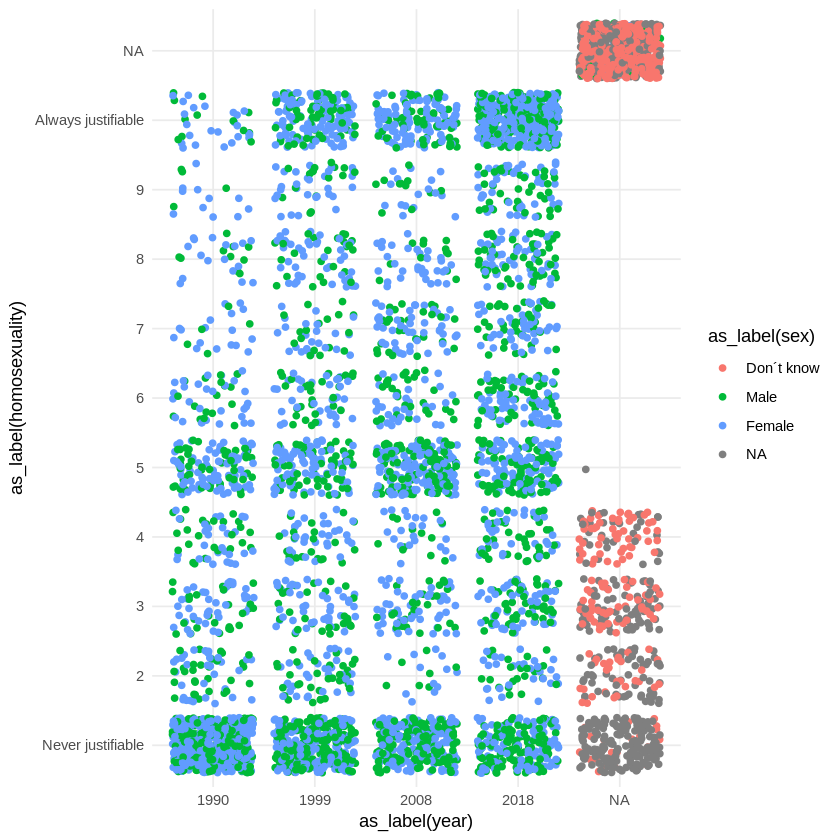

In [8]:
p <- df |> filter(!is.na(homosexuality)) |> # filter NAs
  group_by(sex, year) |> # group by variables
  # plot year on x- and homosexuality on y-axis; use as_label function so that ggplot2  can handle spss/stat data
  ggplot(aes(as_label(year), as_label(homosexuality), color = as_label(sex))) +
    geom_jitter() + # use geom_jitter to show all data points; prevents overplotting
    theme_minimal()

p


In [9]:
png(filename = "plots/plot_homosexuality.png",
width = 21.1,
height = 10.2,
units = "in",
res = 300,
bg = "#ffffff"
)

p

dev.off()


pdf 
  2


-436207616 -427819009      -6529          0          1          2          3 
        62        237        236        105       1550        288        435 
         4          5          6          7          8          9         10 
       293        644        287        217        237        171        803 
       256        512   33554432   50331648   58720255 
         1          2          2          2          1 


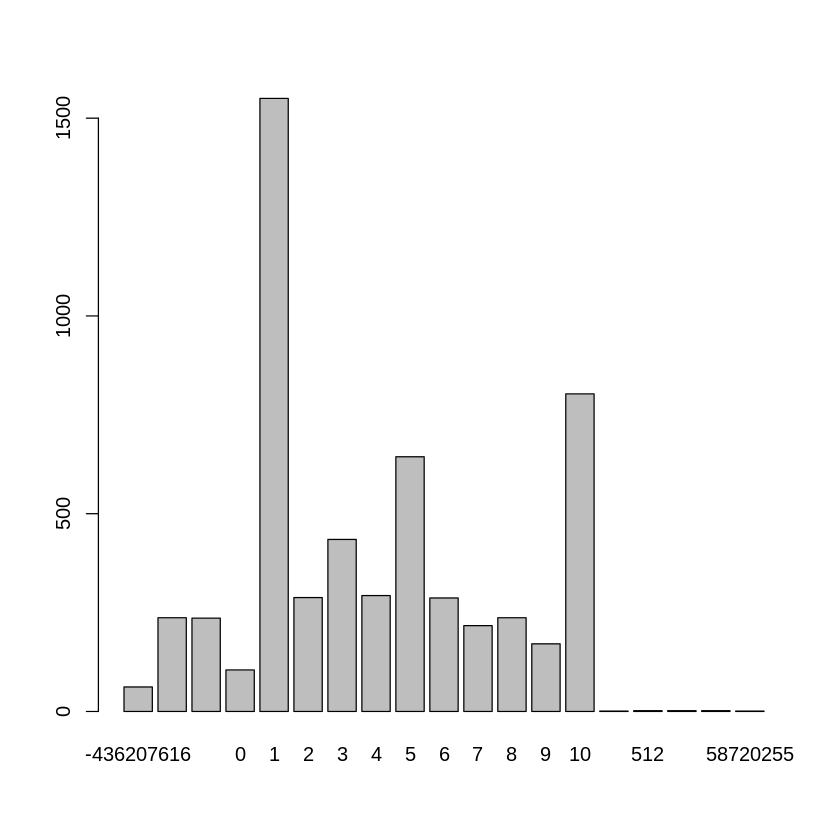

In [11]:
# Use table() to get the frequency table
table <- table(df$homosexuality)
# Printing table

print(table)
# Use barplot to visualize
# a frequency table in a graphic
barplot(table)